## Dataset form Kaggle
Brazilian E-commerce Public Dataset from Olist store 

<img src="https://i.imgur.com/HRhd2Y0.png" width="600" height="350">

This data was imported from the original CSV files into an SQLite database using the following schema:  

<img src="https://terencicp.github.io/public/db-schema.png" width="750">

## <span style="color:orange">Download an existing SQL database from kaggle</span>

In [1]:
import os
import kagglehub
import sqlite3
import pandas as pd

path = kagglehub.dataset_download("terencicp/e-commerce-dataset-by-olist-as-an-sqlite-database")
print("Dataset path:", path)

# Find the .sqlite file 
db_file = [f for f in os.listdir(path) if f.endswith(('.sqlite', '.db'))][0]
db_path = os.path.join(path, db_file)

# Connect to database
db_conn = sqlite3.connect(db_path)

# Verify tables
all_tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", db_conn)
print("Tables in the database: ", all_tables)
print(all_tables.loc[1].values)

# Verify (using differrent method)
# cursor = db_conn.cursor()
# cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
# print(cursor.fetchall())

Dataset path: /Users/kornkanoktripanpitak/.cache/kagglehub/datasets/terencicp/e-commerce-dataset-by-olist-as-an-sqlite-database/versions/1
Tables in the database:                                   name
0   product_category_name_translation
1                             sellers
2                           customers
3                         geolocation
4                         order_items
5                      order_payments
6                       order_reviews
7                              orders
8                            products
9                     leads_qualified
10                       leads_closed
['sellers']


In [2]:
# view table customers
query = """
SELECT *
FROM customers
LIMIT 5
"""
pd.read_sql_query(query, db_conn)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [3]:
# query dat to see how many customers
total_customers = """
SELECT 
    COUNT(DISTINCT customer_unique_id) AS total_customers
FROM customers
"""
pd.read_sql(total_customers, db_conn)

,total_customers
0,96096


## <span style="color:orange">Build a database from csv files and creating an ETL (Extract, Transform, Load) pipeline</span>
#### 1. <span style="color:limegreen">Extract</span>: Load csv files with `pd.read_csv`  
#### 2. <span style="color:limegreen">Transform (Query)</span>: Retrieve data with `pd.read_sql`  
#### 3. <span style="color:limegreen">Load</span>: Convert to SQL with `.to_sql` 

In [4]:
import kagglehub
import os

path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Path to dataset files:", path)

files = os.listdir(path)
print(files)

Path to dataset files: /Users/kornkanoktripanpitak/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2
['olist_sellers_dataset.csv', 'product_category_name_translation.csv', 'olist_orders_dataset.csv', 'olist_dataset', 'olist_order_items_dataset.csv', 'olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv']


In [5]:
import pandas as pd

# Extract dataset
df_orders = pd.read_csv(os.path.join(path, "olist_orders_dataset.csv"))
df_products = pd.read_csv(os.path.join(path, "olist_products_dataset.csv"))
df_products_category = pd.read_csv(os.path.join(path, "product_category_name_translation.csv")) 
df_items = pd.read_csv(os.path.join(path, "olist_order_items_dataset.csv"))
df_sellers = pd.read_csv(os.path.join(path, "olist_sellers_dataset.csv"))
df_customers = pd.read_csv(os.path.join(path, "olist_customers_dataset.csv"))
df_reviews = pd.read_csv(os.path.join(path, "olist_order_reviews_dataset.csv"))
df_payments = pd.read_csv(os.path.join(path, "olist_order_payments_dataset.csv"))
df_locations = pd.read_csv(os.path.join(path, "olist_geolocation_dataset.csv"))

display(df_orders.head(3))
display(df_products.head(3))
display(df_reviews.head(3))
display(df_locations.head(3))


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP


In [6]:
import sqlite3
import pandas as pd

# Connect to SQLite (in-memory) to create database
db_conn = sqlite3.connect(':memory:')

# Convert dataframe to sql table
df_orders.to_sql('orders', db_conn, index=False, if_exists='replace')
df_products.to_sql('products', db_conn, index=False, if_exists='replace')
df_products_category.to_sql('products_category', db_conn, index=False, if_exists='replace')
df_items.to_sql('items', db_conn, index=False, if_exists='replace')
df_sellers.to_sql('sellers', db_conn, index=False, if_exists='replace')
df_customers.to_sql('customers', db_conn, index=False, if_exists='replace')
df_reviews.to_sql('reviews', db_conn, index=False, if_exists='replace')
df_payments.to_sql('payments', db_conn, index=False, if_exists='replace')
df_locations.to_sql('locations', db_conn, index=False, if_exists='replace')

# Query using SQL. read_sql() → executes SQL query
count_query = "SELECT count(*) FROM sqlite_master WHERE type='table'"
table_count = pd.read_sql(count_query, db_conn).iloc[0, 0]
print(f"Total tables in database: {table_count}")

list_query = "SELECT name FROM sqlite_master WHERE type='table'"
tables_df = pd.read_sql(list_query, db_conn)
print(tables_df)

Total tables in database: 9
                name
0             orders
1           products
2  products_category
3              items
4            sellers
5          customers
6            reviews
7           payments
8          locations


In [8]:
# Create view
db_conn.execute("DROP VIEW IF EXISTS fact_sales")

db_conn.execute("""
CREATE VIEW fact_sales AS
SELECT
    o.order_id,
    o.order_purchase_timestamp,
    i.product_id,
    i.price,
    i.freight_value,
    (i.price + i.freight_value) AS revenue,
    pc.product_category_name_english,
    c.customer_city AS branch
FROM orders o
JOIN items i ON o.order_id = i.order_id
JOIN products p ON i.product_id = p.product_id
JOIN products_category pc ON p.product_category_name = pc.product_category_name
JOIN customers c ON o.customer_id = c.customer_id;
""")

# Read view
df = pd.read_sql("SELECT * FROM fact_sales ", db_conn)
display(df)

# df.to_csv('fact_sales.csv', index=False)

,order_id,order_purchase_timestamp,product_id,price,freight_value,revenue,product_category_name_english,branch
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,87285b34884572647811a353c7ac498a,29.99,8.72,38.71,housewares,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,141.46,perfumery,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,aa4383b373c6aca5d8797843e5594415,159.90,19.22,179.12,auto,vianopolis
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,d0b61bfb1de832b15ba9d266ca96e5b0,45.00,27.20,72.20,pet_shop,sao goncalo do amarante
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,65266b2da20d04dbe00c5c2d3bb7859e,19.90,8.72,28.62,stationery,santo andre
...,...,...,...,...,...,...,...,...
111018,63943bddc261676b46f01ca7ac2f7bd8,2018-02-06 12:58:58,f1d4ce8c6dd66c47bbaa8c6781c2a923,174.90,20.10,195.00,baby,praia grande
111019,83c1379a015df1e13d02aae0204711ab,2017-08-27 14:46:43,b80910977a37536adeddd63663f916ad,205.99,65.02,271.01,home_appliances_2,nova vicosa
111020,11c177c8e97725db2631073c19f07b62,2018-01-08 21:28:27,d1c427060a0f73f6b889a5c7c61f2ac4,179.99,40.59,220.58,computers_accessories,japuiba
111021,11c177c8e97725db2631073c19f07b62,2018-01-08 21:28:27,d1c427060a0f73f6b889a5c7c61f2ac4,179.99,40.59,220.58,computers_accessories,japuiba


In [11]:
query = """
SELECT o.order_id, c.customer_city
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
LIMIT 5
"""
pd.read_sql(query, db_conn)

,order_id,customer_city
0,e481f51cbdc54678b7cc49136f2d6af7,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,vianopolis
3,949d5b44dbf5de918fe9c16f97b45f8a,sao goncalo do amarante
4,ad21c59c0840e6cb83a9ceb5573f8159,santo andre


In [13]:
query = """
SELECT order_status, COUNT(*) as n
FROM orders
GROUP BY order_status
ORDER BY n DESC
"""
pd.read_sql(query, db_conn)

,order_status,n
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [23]:
delivered_orders = """
SELECT *
FROM orders
WHERE order_status = 'delivered'
"""
delivered_orders = pd.read_sql(delivered_orders, db_conn)
display(delivered_orders.head(3))
print(f"Number of delivered orders: {len(delivered_orders)}")

delivered_shipped_orders = """
SELECT *
FROM orders
WHERE order_status IN ('delivered', 'shipped');
"""
delivered_shipped_orders = pd.read_sql(delivered_shipped_orders, db_conn)
display(delivered_shipped_orders.head())
print(f"Number of delivered and shipped orders: {len(delivered_shipped_orders)}")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


Number of delivered orders: 96478


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Number of delivered and shipped orders: 97585


In [21]:
query = """
SELECT order_status, COUNT(*) AS n
FROM orders
GROUP BY order_status
HAVING COUNT(*) > 500 -- HAVING should filter after aggregation
"""
pd.read_sql(query, db_conn)

,order_status,n
0,canceled,625
1,delivered,96478
2,shipped,1107
3,unavailable,609


In [24]:
# LEFT JOIN
# Left table = customers. Keeps all customers. Adds order info if available
# Every row = one customer (but may repeat if multiple orders). If no order → order_id = NULL
# Use case: Analyze customers (customer-centric view)
query = """
SELECT o.order_id, c.customer_city
FROM customers c
LEFT JOIN orders o
ON o.customer_id = c.customer_id;
"""
pd.read_sql(query, db_conn)

,order_id,customer_city
0,00e7ee1b050b8499577073aeb2a297a1,franca
1,29150127e6685892b6eab3eec79f59c7,sao bernardo do campo
2,b2059ed67ce144a36e2aa97d2c9e9ad2,sao paulo
3,951670f92359f4fe4a63112aa7306eba,mogi das cruzes
4,6b7d50bd145f6fc7f33cebabd7e49d0f,campinas
...,...,...
99436,6760e20addcf0121e9d58f2f1ff14298,sao paulo
99437,9ec0c8947d973db4f4e8dcf1fbfa8f1b,taboao da serra
99438,fed4434add09a6f332ea398efd656a5c,fortaleza
99439,e31ec91cea1ecf97797787471f98a8c2,canoas


In [25]:
# date/time
query = """
SELECT 
    strftime('%Y', order_purchase_timestamp) AS year,
    COUNT(*) AS n
FROM orders
GROUP BY year
"""
pd.read_sql(query, db_conn)

,year,n
0,2016,329
1,2017,45101
2,2018,54011


`WHERE strftime('%Y', order_purchase_timestamp) BETWEEN '2017' AND '2019'   

= WHERE order_purchase_timestamp >= '2017-01-01' AND order_purchase_timestamp < '2019-01-01'`

In [ ]:
# filter orders in the AM (morning hours) between 2017-2019
query = """
SELECT *
FROM orders
WHERE strftime('%Y', order_purchase_timestamp) BETWEEN '2017' AND '2019' 
    AND CAST(strftime('%H', order_purchase_timestamp) AS INTEGER) < 12
"""
pd.read_sql(query, db_conn)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
2,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00
3,82566a660a982b15fb86e904c8d32918,d3e3b74c766bc6214e0c830b17ee2341,delivered,2018-06-07 10:06:19,2018-06-09 03:13:12,2018-06-11 13:29:00,2018-06-19 12:05:52,2018-07-18 00:00:00
4,85ce859fd6dc634de8d2f1e290444043,059f7fc5719c7da6cbafe370971a8d70,delivered,2017-11-21 00:03:41,2017-11-21 00:14:22,2017-11-23 21:32:26,2017-11-27 18:28:00,2017-12-11 00:00:00
...,...,...,...,...,...,...,...,...
26875,7cc85185736ea7f2d8bc09af7a47cab7,9e870ea67399650e8c3545a25d13e4d0,delivered,2017-05-15 09:46:26,2017-05-15 10:02:45,2017-05-15 14:11:06,2017-05-22 18:05:56,2017-06-07 00:00:00
26876,cfa78b997e329a5295b4ee6972c02979,a2f7428f0cafbc8e59f20e1444b67315,delivered,2017-12-20 09:52:41,2017-12-20 10:09:52,2017-12-20 20:25:25,2018-01-26 15:45:14,2018-01-18 00:00:00
26877,aa04ef5214580b06b10e2a378300db44,f01a6bfcc730456317e4081fe0c9940e,delivered,2017-01-27 00:30:03,2017-01-27 01:05:25,2017-01-30 11:40:16,2017-02-07 13:15:25,2017-03-17 00:00:00
26878,880675dff2150932f1601e1c07eadeeb,47cd45a6ac7b9fb16537df2ccffeb5ac,delivered,2017-02-23 09:05:12,2017-02-23 09:15:11,2017-03-01 10:22:52,2017-03-06 11:08:08,2017-03-22 00:00:00


# Full example for querying data #1
To identify high-activity cities and classify them into high-value vs low-value segments based on average purchase price.

In [9]:
query = """
SELECT 
    c.customer_city,
    COUNT(o.order_id) AS n_orders,
    AVG(i.price) AS avg_price,
    CASE 
        WHEN AVG(i.price) > 100 THEN 'high_value'
        ELSE 'low_value'
    END AS segment
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN items i ON o.order_id = i.order_id
GROUP BY c.customer_city
HAVING n_orders > 50
ORDER BY avg_price DESC;
"""
result1 = pd.read_sql(query, db_conn)
display(result1)

# result1.to_csv("city_purchase_segmentation.csv", index=False)

,customer_city,n_orders,avg_price,segment
0,porto seguro,51,252.746863,high_value
1,campina grande,75,233.340400,high_value
2,divinopolis,164,215.254695,high_value
3,petrolina,69,207.434783,high_value
4,nova lima,104,201.558173,high_value
...,...,...,...,...
288,cubatao,87,80.414138,low_value
289,itapecerica da serra,109,80.172294,low_value
290,vinhedo,115,79.590174,low_value
291,viamao,85,78.295294,low_value


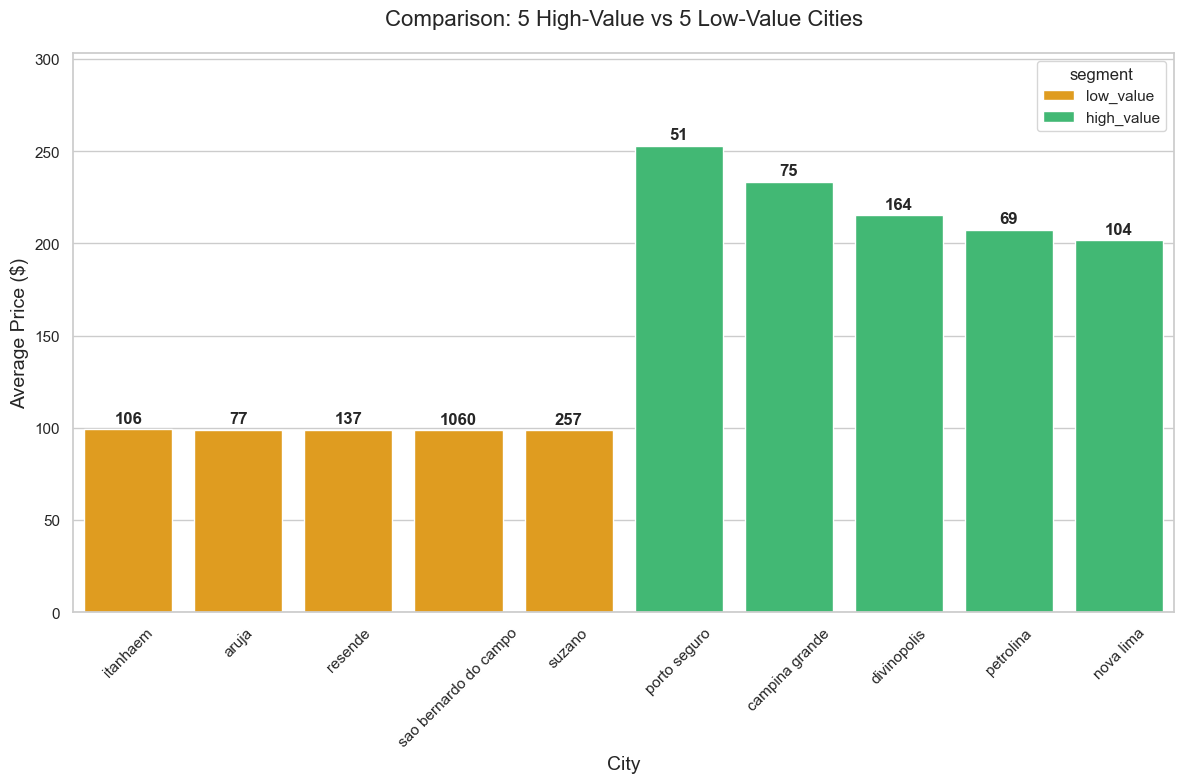

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter 5 high-value and 5 low-value cities
high_v = result1[result1['segment'] == 'high_value'].nlargest(5, 'avg_price')
low_v = result1[result1['segment'] == 'low_value'].nlargest(5, 'avg_price')
balanced_df = pd.concat([high_v, low_v]).sort_values(['segment', 'avg_price'], ascending=[False, False])

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

plot = sns.barplot(
    data=balanced_df, 
    x='customer_city', 
    y='avg_price', 
    hue='segment', 
    palette={'high_value': '#2ecc71', 'low_value': 'orange'},
    dodge=False
)

plt.title('Comparison: 5 High-Value vs 5 Low-Value Cities', fontsize=16, pad=20)
plt.xlabel('City', fontsize=14)
plt.ylabel('Average Price ($)', fontsize=14)
plt.xticks(rotation=45)

for i, (idx, row) in enumerate(balanced_df.iterrows()):
    plt.text(i, row['avg_price'] + 2, int(row['n_orders']), 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylim(0, balanced_df['avg_price'].max() * 1.2)
plt.tight_layout()
plt.show()

# Full example for querying data #2
Identify products (“menu”) ordered in AM (morning) during 2017–2019, and compute: 
- total revenue
- number of orders

In [21]:
query = """
SELECT 
    p.product_category_name AS menu,
    COUNT(DISTINCT o.order_id) AS n_orders,
    SUM(i.price) AS revenue
FROM orders o
JOIN items i 
    ON o.order_id = i.order_id
JOIN products p 
    ON i.product_id = p.product_id
JOIN products_category pc
    ON p.product_category_name = pc.product_category_name_english
WHERE o.order_purchase_timestamp >= '2017-01-01'
  AND o.order_purchase_timestamp < '2018-01-01'
  AND CAST(strftime('%H', o.order_purchase_timestamp) AS INTEGER) < 12
GROUP BY pc.product_category_name_english
ORDER BY revenue DESC;
"""
result2 = pd.read_sql(query, db_conn)
display(result2)

# result2.to_csv("AMorders.csv", index=False)

,menu,n_orders,revenue
0,cool_stuff,576,108190.96
1,pet_shop,188,22400.78
2,consoles_games,191,22130.32
3,audio,53,5551.26
4,market_place,48,4780.97
5,dvds_blu_ray,12,2031.90
6,la_cuisine,3,395.99


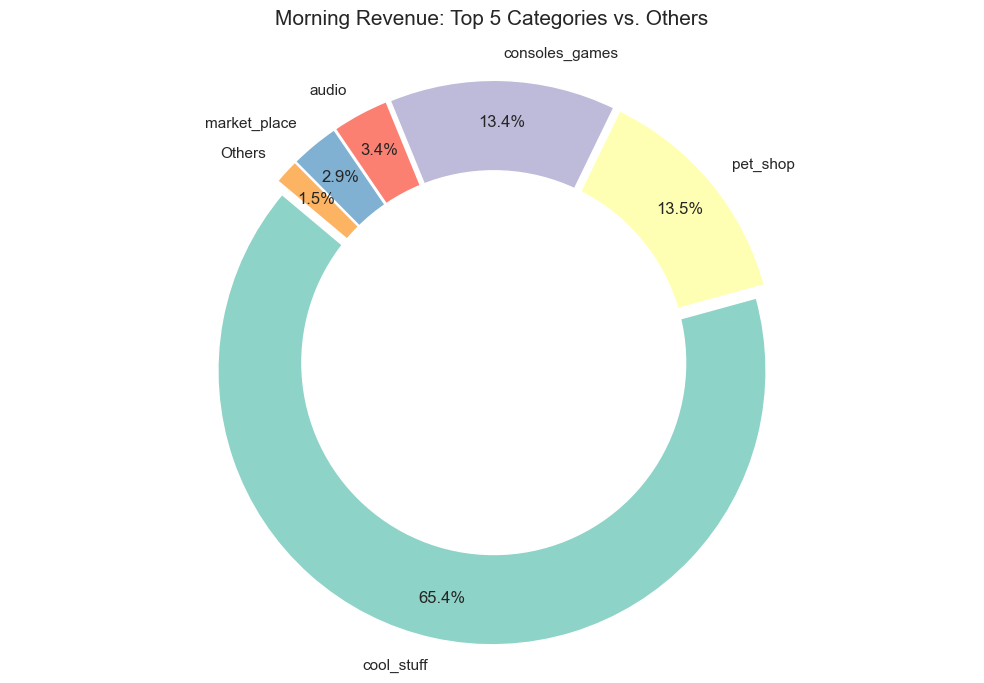

In [23]:
# Prepare the data: Keep Top 5 and group the rest as 'Others'
top_n = 5
top_cats = result2.head(top_n).copy()
others_val = result2.iloc[top_n:]['revenue'].sum()

# Create a summary dataframe for the plot
donut_df = pd.concat([
    top_cats[['menu', 'revenue']], 
    pd.DataFrame({'menu': ['Others'], 'revenue': [others_val]})
], ignore_index=True)

plt.figure(figsize=(10, 7))
colors = plt.cm.Set3(range(len(donut_df))) # Using a soft color palette
plt.pie(
    donut_df['revenue'], 
    labels=donut_df['menu'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, 
    pctdistance=0.85,
    explode=[0.03] * len(donut_df) # Slightly pull slices apart
)

# Transform Pie into Donut
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Morning Revenue: Top 5 Categories vs. Others', fontsize=15, pad=20)
plt.axis('equal') 
plt.tight_layout()
plt.show()